In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("housing.csv")   # change file name if needed
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [35]:
df.replace({
    'yes': 1,
    'no': 0
}, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_8948\656706362.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [36]:
import pandas as pd
df = pd.get_dummies(df, drop_first=True)

In [37]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

feature_columns = X.columns   # save structure

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
y_pred = model.predict(X_test)

c:\Users\DELL\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


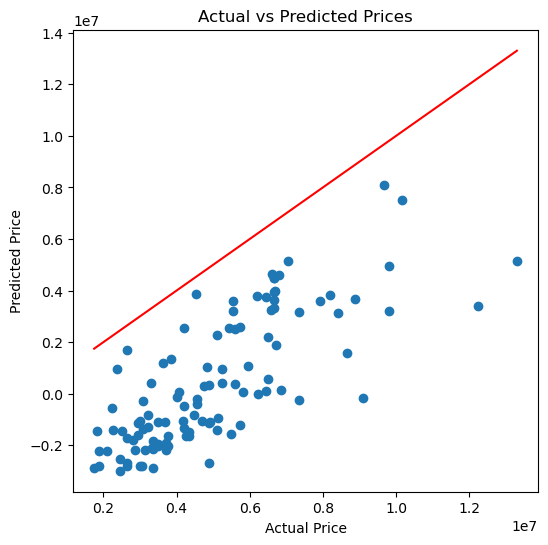

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 23606843714373.945
R2 Score: -3.6703958128538092


In [44]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

new_data = pd.DataFrame({
    'area': np.random.randint(1000, 8000, n),
    'bedrooms': np.random.randint(1, 6, n),
    'bathrooms': np.random.randint(1, 4, n),
    'stories': np.random.randint(1, 4, n),
    'mainroad': np.random.choice(['yes', 'no'], n),
    'guestroom': np.random.choice(['yes', 'no'], n),
    'basement': np.random.choice(['yes', 'no'], n),
    'hotwaterheating': np.random.choice(['yes', 'no'], n),
    'airconditioning': np.random.choice(['yes', 'no'], n),
    'parking': np.random.randint(0, 4, n),
    'prefarea': np.random.choice(['yes', 'no'], n),
    'furnishingstatus': np.random.choice(
        ['furnished', 'semi-furnished', 'unfurnished'], n
    )
})

In [45]:
new_data_encoded = pd.get_dummies(new_data)
new_data_encoded = new_data_encoded.reindex(columns=feature_columns, fill_value=0)

In [46]:
new_data_scaled = scaler.transform(new_data_encoded)

In [47]:
predictions = model.predict(new_data_scaled)

c:\Users\DELL\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [48]:
new_data['price'] = predictions

In [49]:
new_data.to_csv("30_house_predictions.csv", index=False)